# Phase 1: Quick Diagnostics — Participation Ratio & Conditional CKA

**Goal**: Establish baseline numbers before deeper analysis.
- 1A: Does STP change the effective dimensionality of representations?
- 1B: Does CKA break down on specific input types (synth vs spider, short vs long)?

In [1]:
from phase1_diagnostics import (
    load_chat_texts,
    stratify_by_target_length,
    layerwise_participation_ratio,
    plot_participation_ratio,
    conditional_cka,
    plot_conditional_cka,
    eigenspectrum,
    collect_masked_activations,
    load_hooked_model,
)

MODELS = {
    "NTP": "/home/jay/repos/llm-jepa/output-exp1-regular",
    "STP": "/home/jay/repos/llm-jepa/output-exp1-stp",
}
N_LAYERS = 16
SEQ_LEN = 128
BATCH_SIZE = 8


## Load Data

Apply the chat template so tokens match what the model saw during training.

In [2]:
synth_texts, synth_msgs = load_chat_texts("../datasets/synth_test.jsonl")
spider_texts, spider_msgs = load_chat_texts("../datasets/spider_test.jsonl")

print(f"Synth test: {len(synth_texts)} examples")
print(f"Spider test: {len(spider_texts)} examples")
print(f"\nExample (first 200 chars):\n{synth_texts[0][:200]}")

Synth test: 2000 examples
Spider test: 1447 examples

Example (first 200 chars):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 31 Mar 2026

Convert natural language to regular expression.<|eot_id|><|start_header_id|>


## 1A: Participation Ratio

PR = (sum λ)² / sum(λ²). Measures how many dimensions the model uses.
If STP concentrates information into fewer directions, PR drops.
If it spreads information more evenly, PR rises.

We run on synth_test (in-distribution) first, then spider_test.

In [3]:
# Use a subset for speed — 256 examples gives ~32k tokens at seq_len=128
pr_texts = synth_texts[:256]

pr_results = {}
for label, model_path in MODELS.items():
    print(f"\n{label}:")
    pr_results[label] = layerwise_participation_ratio(
        model_path, pr_texts,
        n_layers=N_LAYERS, batch_size=BATCH_SIZE, seq_len=SEQ_LEN,
    )


NTP:
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  (18222 non-padding tokens)
  Layer  0: PR = 1.2
  Layer  1: PR = 1.0
  Layer  2: PR = 1.0
  Layer  3: PR = 1.0
  Layer  4: PR = 1.0
  Layer  5: PR = 1.0
  Layer  6: PR = 1.0
  Layer  7: PR = 1.0
  Layer  8: PR = 1.0
  Layer  9: PR = 1.0
  Layer 10: PR = 1.0
  Layer 11: PR = 1.0
  Layer 12: PR = 1.0
  Layer 13: PR = 1.0
  Layer 14: PR = 1.0
  Layer 15: PR = 4.0

STP:
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  (18222 non-padding tokens)
  Layer  0: PR = 1.3
  Layer  1: PR = 1.0
  Layer  2: PR = 1.0
  Layer  3: PR = 1.0
  Layer  4: PR = 1.0
  Layer  5: PR = 1.0
  Layer  6: PR = 1.0
  Layer  7: PR = 1.0
  Layer  8: PR = 1.0
  Layer  9: PR = 1.0
  Layer 10: PR = 1.0
  Layer 11: PR = 1.0
  Layer 12: PR = 1.0
  Layer 13: PR = 1.0
  Layer 14: PR = 1.0
  Layer 15: PR = 3.3


In [4]:
# Eigenspectrum diagnostic: what is PR actually telling us?
# PR≈1 means one eigenvalue dominates. Inspect the spectrum to confirm.
from phase1_diagnostics import eigenspectrum, collect_masked_activations, load_hooked_model
import torch

print("Layer 15 eigenspectrum (top 20 eigenvalues, NTP):")
model_ntp = load_hooked_model(MODELS["NTP"])
acts = collect_masked_activations(model_ntp, synth_texts[:128], n_layers=16, batch_size=8, seq_len=128)
del model_ntp; torch.cuda.empty_cache()

for layer_idx in [0, 8, 15]:
    name = f"blocks.{layer_idx}.hook_resid_post"
    eigvals, cumvar = eigenspectrum(acts[name], top_k=20)
    print(f"  Layer {layer_idx}:")
    print(f"    Top 5 eigenvalues: {eigvals[:5].round(3)}")
    print(f"    Var explained by top 1/5/10: {cumvar[0]:.3f} / {cumvar[4]:.3f} / {cumvar[9]:.3f}")


Layer 15 eigenspectrum (top 20 eigenvalues, NTP):
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  Layer 0:
    Top 5 eigenvalues: [17.277  0.176  0.092  0.075  0.062]
    Var explained by top 1/5/10: 0.897 / 0.918 / 0.932
  Layer 8:
    Top 5 eigenvalues: [8.584938e+03 2.437000e+00 1.107000e+00 1.084000e+00 7.370000e-01]
    Var explained by top 1/5/10: 0.998 / 0.998 / 0.999
  Layer 15:
    Top 5 eigenvalues: [220.91   18.866  11.944  10.223   9.045]
    Var explained by top 1/5/10: 0.496 / 0.608 / 0.680


interpretation: lora is really only impacting the final layer, and even then it's minimal. So what is it doing?

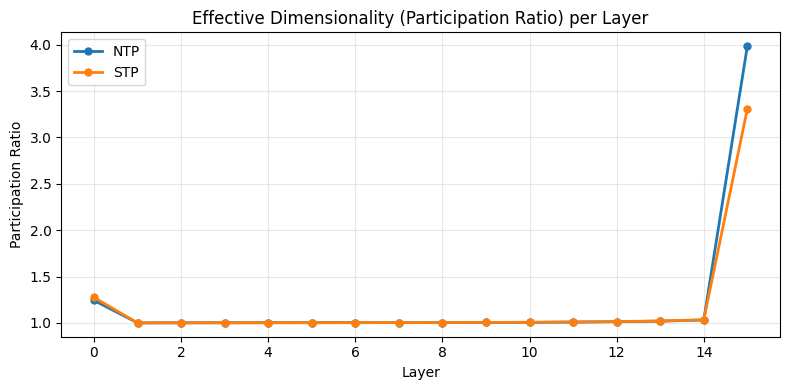

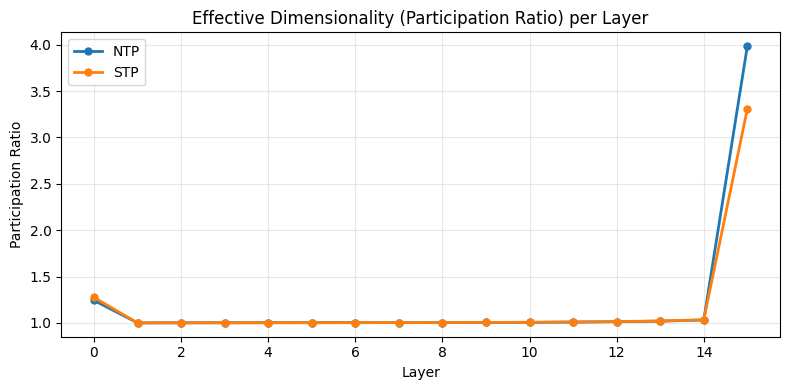

In [4]:
plot_participation_ratio(pr_results, save_path="phase1_pr_synth.png")


NTP (spider):
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  (24125 non-padding tokens)
  Layer  0: PR = 1.3
  Layer  1: PR = 1.0
  Layer  2: PR = 1.0
  Layer  3: PR = 1.0
  Layer  4: PR = 1.0
  Layer  5: PR = 1.0
  Layer  6: PR = 1.0
  Layer  7: PR = 1.0
  Layer  8: PR = 1.0
  Layer  9: PR = 1.0
  Layer 10: PR = 1.0
  Layer 11: PR = 1.0
  Layer 12: PR = 1.0
  Layer 13: PR = 1.0
  Layer 14: PR = 1.0
  Layer 15: PR = 6.7

STP (spider):
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  (24125 non-padding tokens)
  Layer  0: PR = 1.4
  Layer  1: PR = 1.0
  Layer  2: PR = 1.0
  Layer  3: PR = 1.0
  Layer  4: PR = 1.0
  Layer  5: PR = 1.0
  Layer  6: PR = 1.0
  Layer  7: PR = 1.0
  Layer  8: PR = 1.0
  Layer  9: PR = 1.0
  Layer 10: PR = 1.0
  Layer 11: PR = 1.0
  Layer 12: PR = 1.0
  Layer 13: PR = 1.0
  Layer 14: PR = 1.1
  Layer 15: PR = 5.2


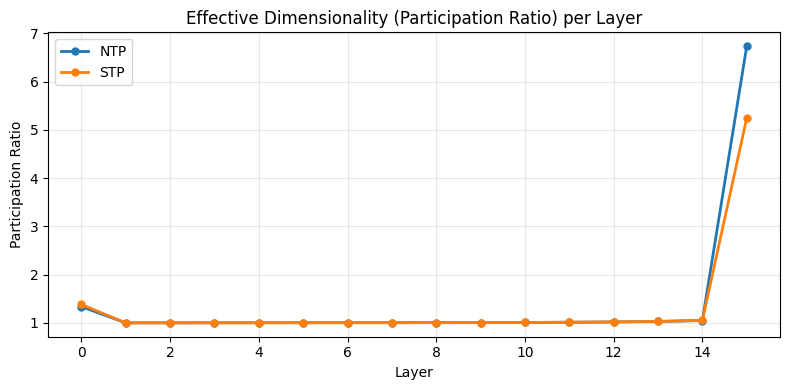

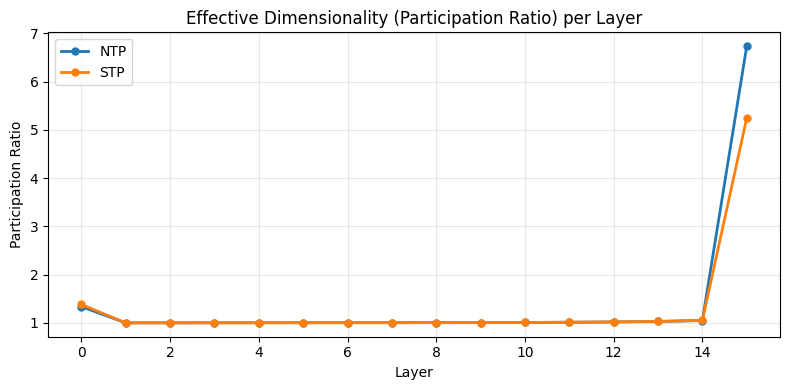

In [5]:
# Repeat on spider for comparison
pr_spider_texts = spider_texts[:256]

pr_spider = {}
for label, model_path in MODELS.items():
    print(f"\n{label} (spider):")
    pr_spider[label] = layerwise_participation_ratio(
        model_path, pr_spider_texts,
        n_layers=N_LAYERS, batch_size=BATCH_SIZE, seq_len=SEQ_LEN,
    )

plot_participation_ratio(pr_spider, save_path="phase1_pr_spider.png")

## 1B: Conditional CKA

Global CKA was ~1.0. Does it drop when we condition on specific input types?

Groups:
- synth short/medium/long (by regex target length)
- spider (out-of-distribution structured output)

In [19]:
print("Stratifying synth by target length:")
synth_buckets = stratify_by_target_length(synth_msgs, synth_texts)

Stratifying synth by target length:
  short: 676 examples
  medium: 712 examples
  long: 612 examples


In [20]:
# Build text groups: synth buckets + spider + openwebtext baseline
from datasets import load_dataset

owt_ds = load_dataset("Skylion007/openwebtext", split="train", streaming=True)
owt_texts = [ex["text"][:512] for ex, _ in zip(owt_ds, range(128))]

text_groups = {
    "synth_short": synth_buckets["short"][:256],
    "synth_medium": synth_buckets["medium"][:256],
    "synth_long": synth_buckets["long"][:256],
    "spider": spider_texts[:256],
    "openwebtext": owt_texts,
}

for name, group in text_groups.items():
    print(f"{name}: {len(group)} texts")

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

synth_short: 256 texts
synth_medium: 256 texts
synth_long: 256 texts
spider: 256 texts
openwebtext: 128 texts


In [21]:
cka_results = conditional_cka(
    MODELS["NTP"], MODELS["STP"],
    text_groups,
    layers=[0, 4, 8, 12, 15],
    batch_size=BATCH_SIZE,
    seq_len=SEQ_LEN,
)

Loading model A...
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
Loading model B...
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
Computing CKA...
  synth_short  layer  0: CKA = 0.999984
  synth_short  layer  4: CKA = 0.999995
  synth_short  layer  8: CKA = 0.999995
  synth_short  layer 12: CKA = 0.999995
  synth_short  layer 15: CKA = 0.999108
  synth_medium layer  0: CKA = 0.999984
  synth_medium layer  4: CKA = 0.999999
  synth_medium layer  8: CKA = 0.999999
  synth_medium layer 12: CKA = 0.999999
  synth_medium layer 15: CKA = 0.999082
  synth_long   layer  0: CKA = 0.999985
  synth_long   layer  4: CKA = 0.999999
  synth_long   layer  8: CKA = 0.999999
  synth_long   layer 12: CKA = 0.999999
  synth_long   layer 15: CKA = 0.999018
  spider       layer  0: CKA = 0.999983
  spider       layer  4: CKA = 1.000000
  spider       layer  8: CKA = 1.000000
  spider       layer 12: CKA = 0.999999
  spider       layer 15: 

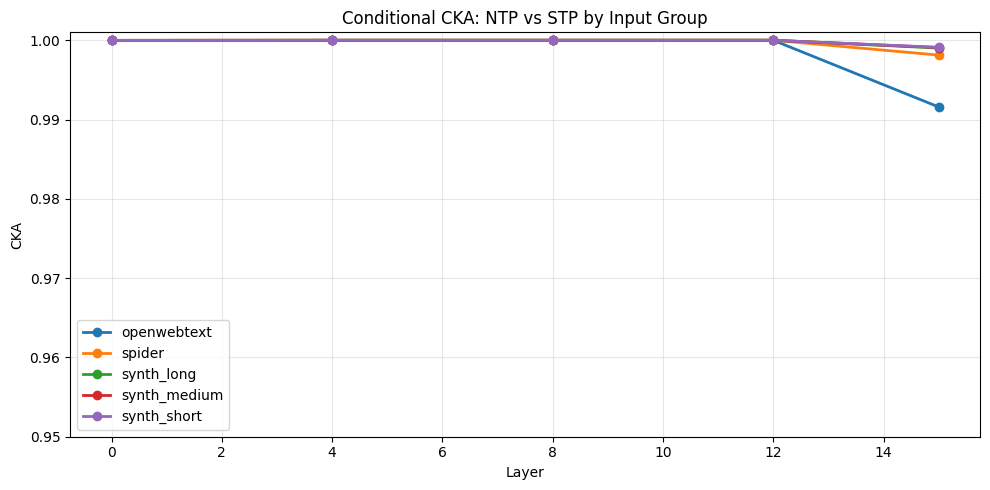

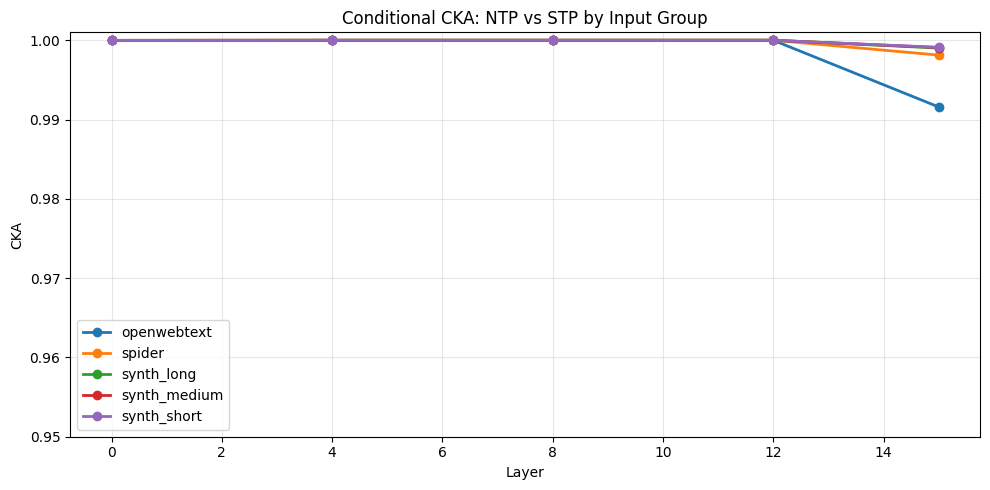

In [22]:
plot_conditional_cka(cka_results, save_path="phase1_conditional_cka.png")

## Summary

Interpret results here after running.

In [23]:
# Print a compact summary table
print("=" * 60)
print("PARTICIPATION RATIO (synth_test)")
print(f"{'Layer':>6}  {'NTP':>8}  {'STP':>8}  {'Diff':>8}  {'%Diff':>8}")
for i in range(N_LAYERS):
    ntp_pr = pr_results["NTP"][i]
    stp_pr = pr_results["STP"][i]
    diff = stp_pr - ntp_pr
    pct = 100 * diff / ntp_pr if ntp_pr > 0 else 0
    print(f"{i:>6}  {ntp_pr:>8.1f}  {stp_pr:>8.1f}  {diff:>+8.1f}  {pct:>+7.1f}%")

print()
print("CONDITIONAL CKA")
layers = [0, 4, 8, 12, 15]
groups = sorted(set(g for g, _ in cka_results.keys()))
header = f"{'Group':>14}" + "".join(f"  L{l:<3}" for l in layers)
print(header)
for g in groups:
    vals = "".join(f"  {cka_results.get((g, l), float('nan')):.4f}" for l in layers)
    print(f"{g:>14}{vals}")

PARTICIPATION RATIO (synth_test)
 Layer       NTP       STP      Diff     %Diff
     0       1.1       1.1      +0.0     +1.3%
     1       1.0       1.0      +0.0     +0.0%
     2       1.0       1.0      +0.0     +0.0%
     3       1.0       1.0      +0.0     +0.0%
     4       1.0       1.0      +0.0     +0.0%
     5       1.0       1.0      +0.0     +0.0%
     6       1.0       1.0      +0.0     +0.0%
     7       1.0       1.0      +0.0     +0.0%
     8       1.0       1.0      +0.0     +0.0%
     9       1.0       1.0      +0.0     +0.0%
    10       1.0       1.0      +0.0     +0.0%
    11       1.0       1.0      +0.0     +0.0%
    12       1.0       1.0      +0.0     +0.1%
    13       1.0       1.0      +0.0     +0.1%
    14       1.0       1.0      +0.0     +0.1%
    15       2.6       2.3      -0.4    -14.0%

CONDITIONAL CKA
         Group  L0    L4    L8    L12   L15 
   openwebtext  1.0000  1.0000  1.0000  1.0000  0.9916
        spider  1.0000  1.0000  1.0000  1.0000  0.9